Вам необходимо доделать задание с семинара, которое заключается в решении задачи классификации на датасете mnist. Задание нужно сдать в виде Jupyter Notebook с запускаемым кодом, которым можно воспроизвести лучшую модель.

Подробное описание задания:

Скачайте датасет mnist
Напишите модель, подобную модели с первой части семинара.
Выведите summary модели.
Обучите модель, добавив коллбек построения графиков обучения, напишите выводы: сошлась ли модель по итогам обучения.
Сравните несколько архитектур, в том числе с различным количеством слоёв и подберите оптимальную. Обязательно используйте dropout и batchnorm и поясните свои выводы. Также можно попробовать различные активации в скрытых слоях.
В конце напишите выводы и отчет о рассмотренных моделях. Отчёт должен быть в виде таблички, в которой описан номер эксперимента, минимальная ошибка на валидации, 4 классификационные метрики на тесте: аccuracy, precision, recall и f1-score, к отчету должно прилагаться описание. Выводы ожидаются в свободной форме и должны содержать информацию о том, почему, по вашему мнению, именно эта архитектура из рассмотренных получила наилучший скор на тесте.
Ссылки на туториалы с документацией и начало решения есть в тетрадке, приложенной к уроку.

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from torchvision import datasets

mnist = datasets.MNIST(root='mnist', download=True)

mnist

Dataset MNIST
    Number of datapoints: 60000
    Root location: mnist
    Split: Train

In [5]:
from torchvision.transforms import ToTensor


train_ds = datasets.MNIST(root='mnist', train=True, download=True, transform=ToTensor())
test_ds = datasets.MNIST(root='mnist', train=False, download=True, transform=ToTensor())

from torch.utils.data import DataLoader

train_dl = DataLoader(train_ds, batch_size=64, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=64, shuffle=True)


In [6]:
from torch import nn

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=784, out_features=512),
    nn.ReLU(),
    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, 10),
)

In [15]:
from torch import optim

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)

In [16]:
def run(model, dataloader, loss_func, optimizer=None):
    # set the model to evaluation or training mode
    if optimizer == None:
        model.eval()
    else:
        model.train()

    total_loss = 0

    for X, y in dataloader:
        # compute prediction
        logits = model(X)
        # compute loss
        loss = loss_func(logits, y)
        # save loss
        total_loss += loss.item()
        if optimizer != None:
            # compute gradients
            loss.backward()
            # do optimizer step
            optimizer.step()
            # clear gradients
            optimizer.zero_grad()

    return total_loss / len(dataloader)

In [17]:
from IPython.display import clear_output

def show_losses(train_loss_hist, test_loss_hist):
    clear_output()

    plt.figure(figsize=(12,4))

    plt.subplot(1, 2, 1)
    plt.title('Train Loss')
    plt.plot(np.arange(len(train_loss_hist)), train_loss_hist)
    plt.yscale('log')
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.title('Test Loss')
    plt.plot(np.arange(len(test_loss_hist)), test_loss_hist)
    plt.yscale('log')
    plt.grid()

    plt.show()

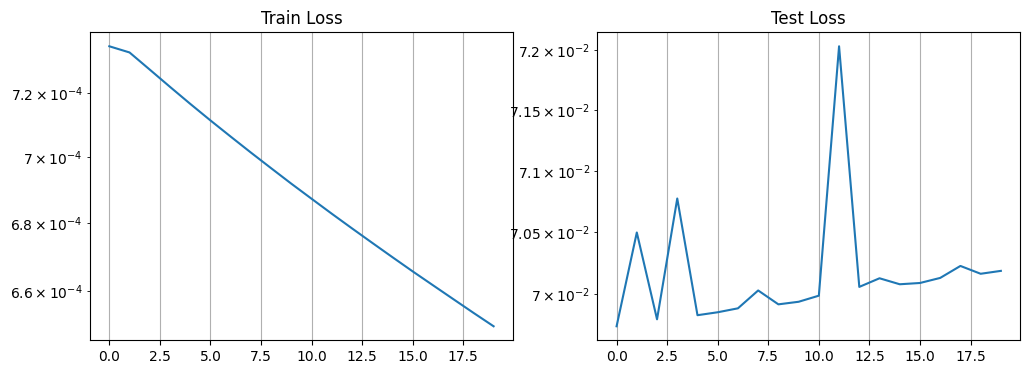

In [18]:
BATCH_SIZE = 100
NUM_EPOCHS = 20

# your code here
#train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE)
#test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

train_loss_hist = []
test_loss_hist = []

for i in range(NUM_EPOCHS):
    train_loss = run(model, train_dl, loss_func, optimizer)
    train_loss_hist.append(train_loss)
    test_loss = run(model, test_dl, loss_func)
    test_loss_hist.append(test_loss)


show_losses(train_loss_hist, test_loss_hist)